In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Permitir que TensorFlow use la memoria GPU progresivamente
gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print("No se pudo configurar memory growth:", error)

# Configuración general
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Entrenamiento
EPOCHS_FASE1 = 25
EPOCHS_FASE2 = 15

# Directorios
BASE_DIR = "../dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Clases
CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

N_CLASSES = len(CLASSES)

print("TensorFlow:", tf.__version__)
print("GPU detectada:", gpus)
print("Train:", os.listdir(TRAIN_DIR))
print("Valid:", os.listdir(VALID_DIR))
print("Test:", os.listdir(TEST_DIR))

TensorFlow: 2.21.0
GPU detectada: []
Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Valid: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [2]:
# Conteo de imágenes por clase

def contar_imagenes_por_clase(ruta):
    extensiones_validas = (".jpg", ".jpeg", ".png", ".webp")

    conteo = {}

    for clase in CLASSES:
        carpeta = os.path.join(ruta, clase)

        if not os.path.isdir(carpeta):
            raise FileNotFoundError(
                f"No se encontró la carpeta de la clase '{clase}': {carpeta}"
            )

        conteo[clase] = sum(
            1
            for archivo in os.listdir(carpeta)
            if (
                os.path.isfile(os.path.join(carpeta, archivo))
                and archivo.lower().endswith(extensiones_validas)
            )
        )

    return conteo


train_count = contar_imagenes_por_clase(TRAIN_DIR)
valid_count = contar_imagenes_por_clase(VALID_DIR)
test_count = contar_imagenes_por_clase(TEST_DIR)

print("Train:", train_count)
print("Valid:", valid_count)
print("Test:", test_count)

print("\nTotales:")
print("Train:", sum(train_count.values()))
print("Valid:", sum(valid_count.values()))
print("Test:", sum(test_count.values()))

Train: {'cardboard': 282, 'glass': 350, 'metal': 287, 'paper': 415, 'plastic': 337, 'trash': 95}
Valid: {'cardboard': 60, 'glass': 75, 'metal': 61, 'paper': 89, 'plastic': 72, 'trash': 20}
Test: {'cardboard': 61, 'glass': 76, 'metal': 62, 'paper': 90, 'plastic': 73, 'trash': 22}

Totales:
Train: 1766
Valid: 377
Test: 384


In [3]:
# Cálculo de class_weights

from sklearn.utils.class_weight import compute_class_weight

# Relación entre el nombre de cada clase y su índice
class_indices = {
    clase: indice
    for indice, clase in enumerate(CLASSES)
}

# Construir una lista con la clase de cada imagen de entrenamiento
y_train = []

for clase in CLASSES:
    indice_clase = class_indices[clase]
    cantidad_imagenes = train_count[clase]

    y_train.extend([indice_clase] * cantidad_imagenes)

y_train = np.array(y_train)

# Calcular pesos balanceados
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=y_train
)

# Convertir a diccionario compatible con Keras
class_weights = {
    indice: float(peso)
    for indice, peso in enumerate(class_weights_array)
}

print("Class weights:")

for indice, peso in class_weights.items():
    print(f"{indice} - {CLASSES[indice]:10s}: {peso:.4f}")

Class weights:
0 - cardboard : 1.0437
1 - glass     : 0.8410
2 - metal     : 1.0256
3 - paper     : 0.7092
4 - plastic   : 0.8734
5 - trash     : 3.0982


In [4]:
# Creación de entrenamiento

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Guardar antes de aplicar prefetch
class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Clases:", class_names)

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.
Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
# Data augmentation

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
    ],
    name="data_augmentation"
)

In [6]:
# Construcción del modelo para la Fase 1

base_model = keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

# Fase 1: congelar completamente MobileNetV3
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(
    N_CLASSES,
    activation="softmax"
)(x)

model_mobilenet = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="trashnet_mobilenetv3"
)

model_mobilenet.summary()

Model: "trashnet_mobilenetv3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,750 (3.87 MB)

 Trainable params: 74,630 (291.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [7]:
# Entrenamiento Fase 1

model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=3e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history_fase1 = model_mobilenet.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_fase1,
    verbose=1
)

Epoch 1/25


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 626ms/step - accuracy: 0.3686 - loss: 1.5739 - val_accuracy: 0.5756 - val_loss: 1.1098 - learning_rate: 3.0000e-04
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.6178 - loss: 1.0844 - val_accuracy: 0.6684 - val_loss: 0.8656 - learning_rate: 3.0000e-04
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 476ms/step - accuracy: 0.6897 - loss: 0.9192 - val_accuracy: 0.6923 - val_loss: 0.7641 - learning_rate: 3.0000e-04
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 523ms/step - accuracy: 0.7327 - loss: 0.7745 - val_accuracy: 0.7188 - val_loss: 0.7325 - learning_rate: 3.0000e-04
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 534ms/step - accuracy: 0.7503 - loss: 0.7122 - val_accuracy: 0.7745 - val_loss: 0.6649 - learning_rate: 3.0000e-04
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 126ms/step - accuracy: 0.7605 - loss: 0.6721 - val_accuracy: 0.7878 - val_loss: 0.6336 - learning_rate: 3.0000e-04
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.790

In [8]:
# Guardar y evaluar la Fase 1

os.makedirs("modelo_guardado", exist_ok=True)

RUTA_MODELO_FASE1 = (
    "modelo_guardado/"
    "trashnet_mobilenetv3_224_fase1.keras"
)

model_mobilenet.save(RUTA_MODELO_FASE1)

print("Modelo Fase 1 guardado en:")
print(RUTA_MODELO_FASE1)

val_loss_fase1, val_accuracy_fase1 = model_mobilenet.evaluate(
    valid_ds,
    verbose=1
)

print(f"\nValidation loss Fase 1: {val_loss_fase1:.4f}")
print(f"Validation accuracy Fase 1: {val_accuracy_fase1:.4f}")
print(f"Validation accuracy Fase 1: {val_accuracy_fase1:.2%}")

Modelo Fase 1 guardado en:
modelo_guardado/trashnet_mobilenetv3_224_fase1.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8647 - loss: 0.3838

Validation loss Fase 1: 0.3838
Validation accuracy Fase 1: 0.8647
Validation accuracy Fase 1: 86.47%


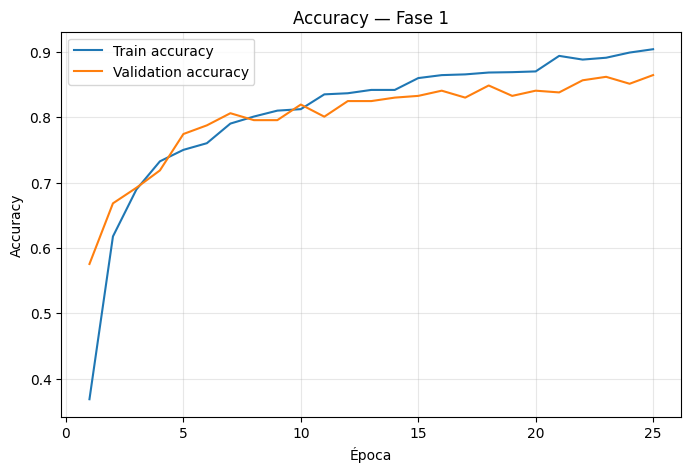

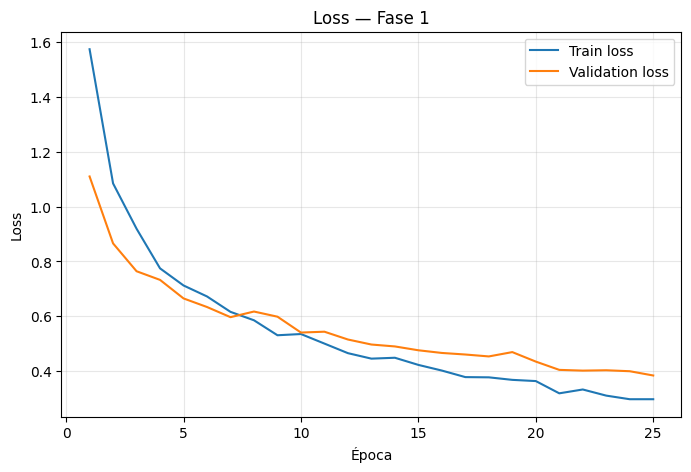

In [9]:
# Gráficos Fase 1

history_dict_fase1 = history_fase1.history

epochs_ran_fase1 = range(
    1,
    len(history_dict_fase1["accuracy"]) + 1
)

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran_fase1,
    history_dict_fase1["accuracy"],
    label="Train accuracy"
)

plt.plot(
    epochs_ran_fase1,
    history_dict_fase1["val_accuracy"],
    label="Validation accuracy"
)

plt.title("Accuracy — Fase 1")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran_fase1,
    history_dict_fase1["loss"],
    label="Train loss"
)

plt.plot(
    epochs_ran_fase1,
    history_dict_fase1["val_loss"],
    label="Validation loss"
)

plt.title("Loss — Fase 1")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
# Fine-tuning de MobileNetv3

# Descongelar el modelo base
base_model.trainable = True

# Mantener congeladas todas las capas excepto las últimas 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Mantener BatchNormalization congeladas para evitar inestabilidad
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Capas totales del modelo base:", len(base_model.layers))
print(
    "Capas entrenables del modelo base:",
    sum(layer.trainable for layer in base_model.layers)
)

model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_mobilenet.summary()

Capas totales del modelo base: 157
Capas entrenables del modelo base: 15


Model: "trashnet_mobilenetv3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,750 (3.87 MB)

 Trainable params: 421,526 (1.61 MB)

 Non-trainable params: 592,224 (2.26 MB)

In [11]:
# Entrenamiento Fase 2

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_fase2 = model_mobilenet.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_fase2,
    verbose=1
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.9020 - loss: 0.2886 - val_accuracy: 0.8647 - val_loss: 0.3645 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9026 - loss: 0.2783 - val_accuracy: 0.8515 - val_loss: 0.3594 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.9077 - loss: 0.2745 - val_accuracy: 0.8515 - val_loss: 0.3599 - learning_rate: 1.0000e-05
Epoch 4/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9034 - loss: 0.2750
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.9032 - loss: 0.2748 - val_accuracy: 0.8568 - val_loss: 0.3632 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.9134 - loss: 0.2530 - val_accuracy: 0.8568 - val_loss: 0.3608 - learning_rate: 5.0000e-06
Epoch 6/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.91

In [12]:
# Evaluación y guardado del modelo final

# Evaluación final sobre el conjunto de test
test_loss, test_accuracy = model_mobilenet.evaluate(
    test_ds,
    verbose=1
)

print("\n===== RESULTADOS FINALES =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.2%}")

# Guardar modelo final
RUTA_MODELO_FINAL = (
    "modelo_guardado/"
    "trashnet_mobilenetv3_224_final.keras"
)

model_mobilenet.save(RUTA_MODELO_FINAL)

print("\nModelo final guardado en:")
print(RUTA_MODELO_FINAL)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8125 - loss: 0.5245

===== RESULTADOS FINALES =====
Test Loss: 0.5245
Test Accuracy: 0.8125
Test Accuracy: 81.25%

Modelo final guardado en:
modelo_guardado/trashnet_mobilenetv3_224_final.keras


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
===== REPORTE DE CLASIFICACIÓN =====

              precision    recall  f1-score   support

   cardboard     0.8750    0.9180    0.8960        61
       glass     0.8750    0.5526    0.6774        76
       metal     0.7024    0.9516    0.8082        62
       paper     0.9059    0.8556    0.8800        90
     plastic     0.8052    0.8493    0.8267        73
       trash     0.6154    0.7273    0.6667        22

    accuracy                         0.8125       384
   macro avg     0.7965    0.8091    0.7925       384
weighted avg     0.8262    0.8125    0.8085       384



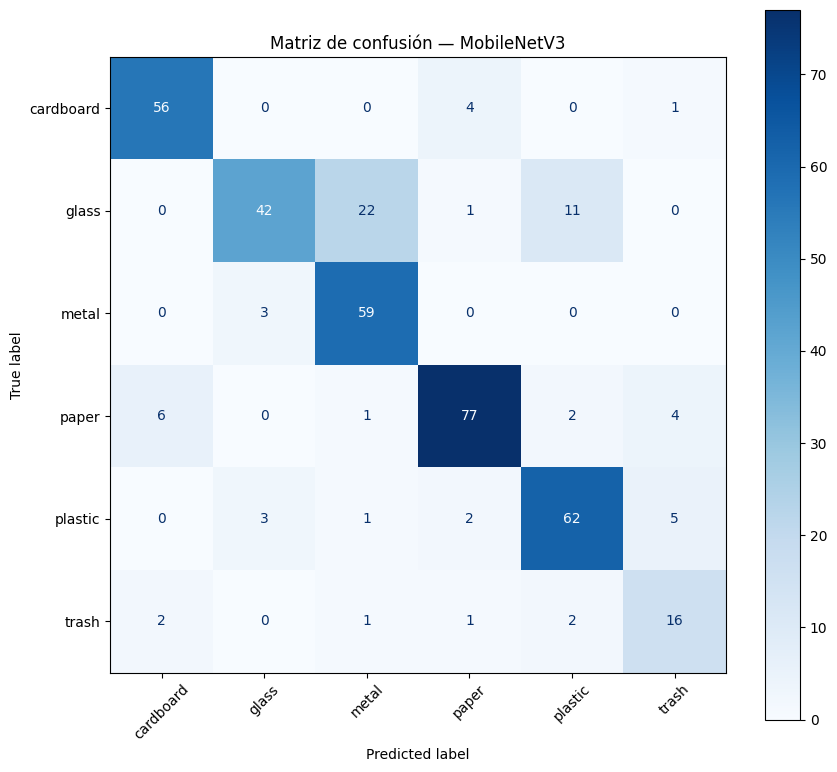

In [13]:
# Matriz de confusión y reporte de clasificación

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Etiquetas reales
y_true = np.concatenate(
    [np.argmax(labels.numpy(), axis=1) for _, labels in test_ds]
)

# Predicciones del modelo
y_prob = model_mobilenet.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

# Reporte por clase
print("===== REPORTE DE CLASIFICACIÓN =====\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASSES,
        digits=4,
        zero_division=0
    )
)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)

fig, ax = plt.subplots(figsize=(9, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Matriz de confusión — MobileNetV3")
plt.tight_layout()
plt.show()

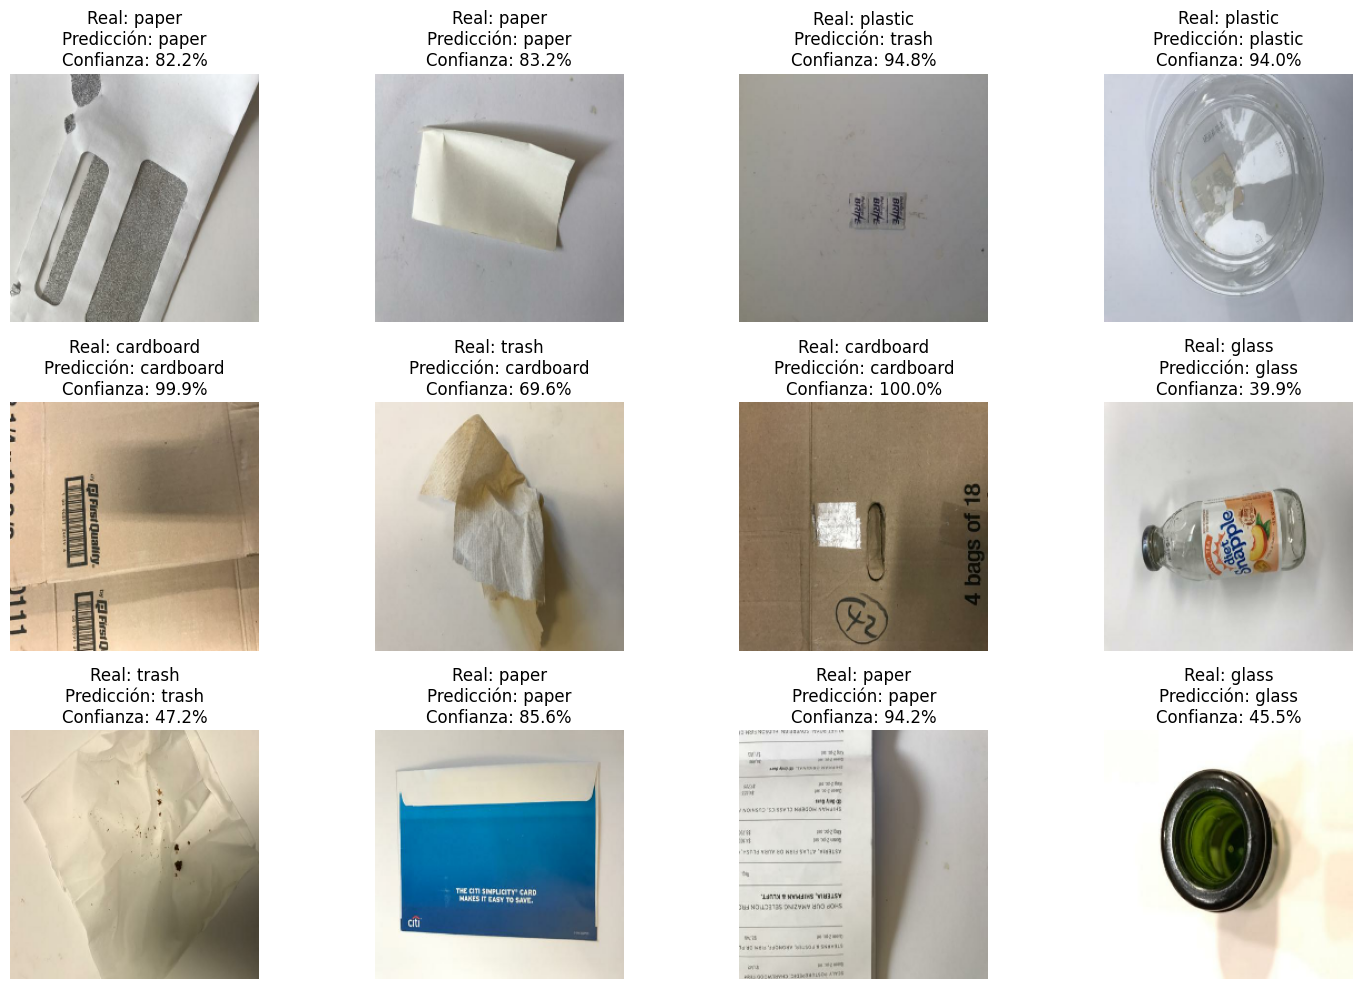

In [14]:
# Visualización de predicciones del conjunto de test

images_all = []
labels_all = []

for images, labels in test_ds:
    images_all.append(images.numpy())
    labels_all.append(labels.numpy())

images_all = np.concatenate(images_all)
labels_all = np.concatenate(labels_all)

indices = np.random.choice(
    len(images_all),
    size=12,
    replace=False
)

selected_images = images_all[indices]
selected_labels = labels_all[indices]

selected_predictions = model_mobilenet.predict(
    selected_images,
    verbose=0
)

plt.figure(figsize=(15, 10))

for i in range(12):
    true_index = np.argmax(selected_labels[i])
    pred_index = np.argmax(selected_predictions[i])

    true_class = CLASSES[true_index]
    predicted_class = CLASSES[pred_index]
    confidence = selected_predictions[i][pred_index] * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(selected_images[i].astype("uint8"))

    plt.title(
        f"Real: {true_class}\n"
        f"Predicción: {predicted_class}\n"
        f"Confianza: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

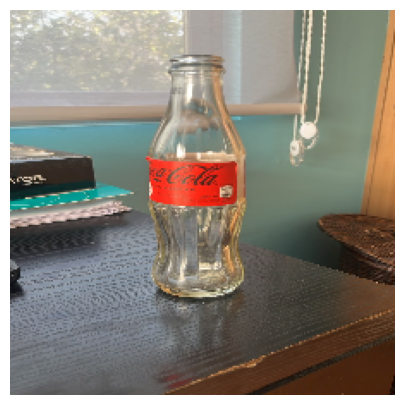

Clase predicha: glass
Confianza: 92.24%

Probabilidades por clase:

cardboard   :   0.00%
glass       :  92.24%
metal       :   0.28%
paper       :   0.00%
plastic     :   7.47%
trash       :   0.01%


In [15]:
# Predicción con imagen externa

from tensorflow.keras.utils import load_img, img_to_array

RUTA_IMAGEN = "../imagenes_a_test/test 1.jpeg"

img = load_img(
    RUTA_IMAGEN,
    target_size=IMG_SIZE
)

img_array = img_to_array(img)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = np.expand_dims(img_array, axis=0)

pred = model_mobilenet.predict(
    img_array,
    verbose=0
)

pred_idx = np.argmax(pred[0])

print(f"Clase predicha: {CLASSES[pred_idx]}")
print(f"Confianza: {pred[0][pred_idx] * 100:.2f}%")

print("\nProbabilidades por clase:\n")

for clase, prob in zip(CLASSES, pred[0]):
    print(f"{clase:12s}: {prob * 100:6.2f}%")

In [16]:
print("=" * 60)
print("RESUMEN DEL MODELO")
print("=" * 60)

print(f"Arquitectura         : MobileNetV3Small")
print(f"Tamaño de entrada    : {IMG_SIZE}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Número de clases     : {N_CLASSES}")

print("\nTransfer learning")
print("- Fase 1: backbone completamente congelado")
print("- Fase 2: últimas 20 capas habilitadas")
print("- BatchNormalization mantenidas congeladas")

print("\nLearning rates")
print("- Fase 1: 3e-4")
print("- Fase 2: 1e-5")

print("\nRegularización")
print("- Data augmentation")
print("- Dropout: 0.35")
print("- Class weights")
print("- EarlyStopping")
print("- ReduceLROnPlateau")

print("\nResultados")
print(f"- Validation accuracy Fase 1: {val_accuracy_fase1:.2%}")
print(f"- Test loss final: {test_loss:.4f}")
print(f"- Test accuracy final: {test_accuracy:.2%}")

print("\nModelo final guardado en:")
print(RUTA_MODELO_FINAL)

RESUMEN DEL MODELO
Arquitectura         : MobileNetV3Small
Tamaño de entrada    : (224, 224)
Batch size           : 32
Número de clases     : 6

Transfer learning
- Fase 1: backbone completamente congelado
- Fase 2: últimas 20 capas habilitadas
- BatchNormalization mantenidas congeladas

Learning rates
- Fase 1: 3e-4
- Fase 2: 1e-5

Regularización
- Data augmentation
- Dropout: 0.35
- Class weights
- EarlyStopping
- ReduceLROnPlateau

Resultados
- Validation accuracy Fase 1: 86.47%
- Test loss final: 0.5245
- Test accuracy final: 81.25%

Modelo final guardado en:
modelo_guardado/trashnet_mobilenetv3_224_final.keras
